# Laporan Tugas Besar: Pembangunan Model pada Berbagai Teknik Pre-processing

**Dataset**: `healthcare-dataset-stroke-data.csv`

**Tujuan**:
Notebook ini bertujuan untuk melakukan analisis komprehensif terhadap berbagai teknik pra-pemrosesan (pre-processing) data dan membandingkan dampaknya terhadap kinerja beberapa algoritma Machine Learning, termasuk **XGBoost**. Berbagai kombinasi preprocessing (scaling, encoding, imbalance handling) diuji secara sistematis untuk menemukan pipeline terbaik.

## STEP 1 - Import Library

### Teori Singkat
Dalam pengembangan model Machine Learning, berbagai library Python digunakan untuk memfasilitasi manipulasi data, visualisasi, dan pemodelan.
- **Pandas & NumPy**: Manipulasi data dan komputasi numerik.
- **Seaborn & Matplotlib**: Visualisasi data.
- **Scikit-learn (sklearn)**: Algoritma ML, evaluasi metrik, dan teknik pre-processing.
- **Imbalanced-learn (imblearn)**: Menangani masalah data tidak seimbang (SMOTE, ADASYN, RandomUnderSampler).
- **XGBoost**: Algoritma ensemble berbasis gradient boosting yang sangat powerful untuk klasifikasi dan regresi.

### Tujuan Step
Menginisialisasi semua fungsi dan modul yang akan digunakan di seluruh tahapan eksperimen.

### Perbedaan dengan Metode Sebelumnya
- Sebelumnya, hanya menggunakan 4 model dasar (Logistic Regression, Decision Tree, Random Forest, KNN biasa).
- Sekarang, ditambahkan **XGBoost** sebagai model ke-5, KNN diubah menjadi **Weighted KNN** (W-KNN) dengan parameter , serta berbagai teknik preprocessing tambahan (MinMaxScaler, RobustScaler, ADASYN, RandomUnderSampler) untuk perbandingan yang lebih komprehensif.

In [1]:
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler

# Handling Imbalance
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Evaluasi
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings('ignore')

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


## STEP 2 - Load Dataset

### Teori Singkat
Proses pemuatan data (data loading) adalah langkah awal sebelum analisis dilakukan. Dataset harus direpresentasikan dalam bentuk struktur data yang dapat diproses oleh mesin, seperti DataFrame pandas.

### Tujuan Step
Membaca dataset `healthcare-dataset-stroke-data.csv` dan menginspeksi beberapa baris awal serta dimensi dari dataset tersebut.

In [2]:
# Load dataset
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# Menampilkan 5 baris pertama dataset
display(df.head())

# Menampilkan ukuran dataset
print(f"Jumlah baris (Data)  : {df.shape[0]}")
print(f"Jumlah kolom (Fitur) : {df.shape[1]}")

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Jumlah baris (Data)  : 5110
Jumlah kolom (Fitur) : 12


### Analisis Hasil
Dataset telah berhasil dimuat dengan 5110 sampel dan 12 fitur. Target dari dataset ini adalah fitur `stroke`, di mana model harus memprediksi apakah seorang pasien berisiko mengalami stroke atau tidak berdasarkan fitur klinis lainnya.

## STEP 3 - Informasi Dataset

### Teori Singkat
Pemeriksaan struktur dataset melibatkan pengamatan tipe data (integer, float, object), keberadaan nilai kosong (missing values), dan keberadaan data duplikat. Analisis deskriptif juga diperlukan untuk melihat distribusi statistik dari fitur numerik.

### Tujuan Step
Mendapatkan pemahaman mendalam tentang tipe data masing-masing kolom dan mengidentifikasi anomali seperti nilai kosong atau baris yang terduplikasi.

In [3]:
# Menampilkan informasi struktur dataframe
print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("STATISTIK DESKRIPTIF (NUMERIK)")
print("=" * 60)
display(df.describe())

print("\n" + "=" * 60)
print("MISSING VALUE PER FITUR")
print("=" * 60)
print(df.isnull().sum())

print("\n" + "=" * 60)
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")
print("=" * 60)

INFORMASI DATASET
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB

STATISTIK DESKRIPTIF (NUMERIK)


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000



MISSING VALUE PER FITUR
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Jumlah baris duplikat: 0


### Analisis Hasil
Berdasarkan hasil eksekusi:
- Terdapat 5 fitur kategorikal (object) dan 7 fitur numerik (int64/float64).
- Fitur `bmi` memiliki 201 missing values yang perlu ditangani.
- Tidak ada baris duplikat dalam dataset.

<br>

---

# 🛠️ FASE PRE-PROCESSING DATA
**Fase ini mencakup serangkaian proses untuk membersihkan, merubah bentuk, dan menstandarisasi data mentah agar dapat dicerna secara optimal oleh algoritma Machine Learning.**

---

<br>

## STEP 4 - Data Cleaning

### Teori Singkat
Data yang kotor (mengandung duplikasi atau missing value) dapat menyebabkan bias dan menurunkan akurasi model. Teknik imputasi yang digunakan:
- **Mean Imputation**: Mengisi missing value dengan rata-rata kolom. Cocok untuk distribusi normal.
- **Median Imputation**: Mengisi dengan nilai tengah. Lebih robust terhadap outlier.

Pada dataset ini, fitur `bmi` memiliki distribusi yang sedikit *right-skewed* sehingga **Median** lebih tepat digunakan dibanding Mean.

### Tujuan Step
Membersihkan dataset dengan menghapus kolom `id`, menangani missing values menggunakan **Median** (lebih robust terhadap outlier), dan menghapus baris duplikat.

### Perbedaan dengan Metode Sebelumnya
- Sebelumnya, missing value ditangani dengan Mean imputation.
- Sekarang, kita menggunakan **Median** karena fitur `bmi` memiliki outlier (max=97.6) yang dapat mendistorsi nilai mean.

In [4]:
# Menghapus kolom 'id' karena tidak memiliki pengaruh prediktif
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Cek distribusi BMI sebelum imputasi
print("Statistik BMI sebelum imputasi:")
print(f"  Mean   : {df['bmi'].mean():.2f}")
print(f"  Median : {df['bmi'].median():.2f}")
print(f"  Skew   : {df['bmi'].skew():.2f}")
print(f"  Max    : {df['bmi'].max():.2f}")

# Imputasi Missing Value pada fitur 'bmi' menggunakan MEDIAN (lebih robust terhadap outlier)
median_bmi = df['bmi'].median()
df['bmi'] = df['bmi'].fillna(median_bmi)
print(f"\nMissing value pada 'bmi' diisi dengan Median: {median_bmi:.2f}")

# Menghapus baris dengan gender='Other' (hanya 1 data, bisa menyebabkan noise)
df = df[df['gender'] != 'Other']
print(f"Baris dengan gender='Other' dihapus (noise reduction)")

# Menghapus data duplikat jika ada
df = df.drop_duplicates()

# Verifikasi ulang
print(f"\nJumlah Missing Value setelah Cleaning:")
print(df.isnull().sum())
print(f"\nUkuran dataset setelah cleaning: {df.shape}")

Statistik BMI sebelum imputasi:
  Mean   : 28.89
  Median : 28.10
  Skew   : 1.06
  Max    : 97.60

Missing value pada 'bmi' diisi dengan Median: 28.10
Baris dengan gender='Other' dihapus (noise reduction)

Jumlah Missing Value setelah Cleaning:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Ukuran dataset setelah cleaning: (5109, 11)


### Analisis Hasil
- Kolom `id` berhasil dihapus karena tidak relevan untuk prediksi.
- Missing value pada `bmi` diisi dengan Median (lebih robust terhadap outlier dibanding Mean).
- Baris dengan `gender='Other'` dihapus karena hanya 1 data dan bisa menjadi noise.
- Dataset kini bersih dari NaN dan siap untuk tahap selanjutnya.

## STEP 5 - Exploratory Data Analysis (EDA)

### Teori Singkat
EDA adalah proses investigasi awal pada data untuk menemukan pola, mendeteksi anomali, serta menguji hipotesis. Pada dataset medis, EDA sangat penting untuk:
1. Mengidentifikasi **class imbalance** pada target variable.
2. Mendeteksi **outlier** yang dapat mempengaruhi model.
3. Memahami **korelasi** antar fitur untuk feature selection.

### Tujuan Step
Memvisualisasikan distribusi data, korelasi, dan mengidentifikasi masalah yang perlu ditangani di preprocessing.

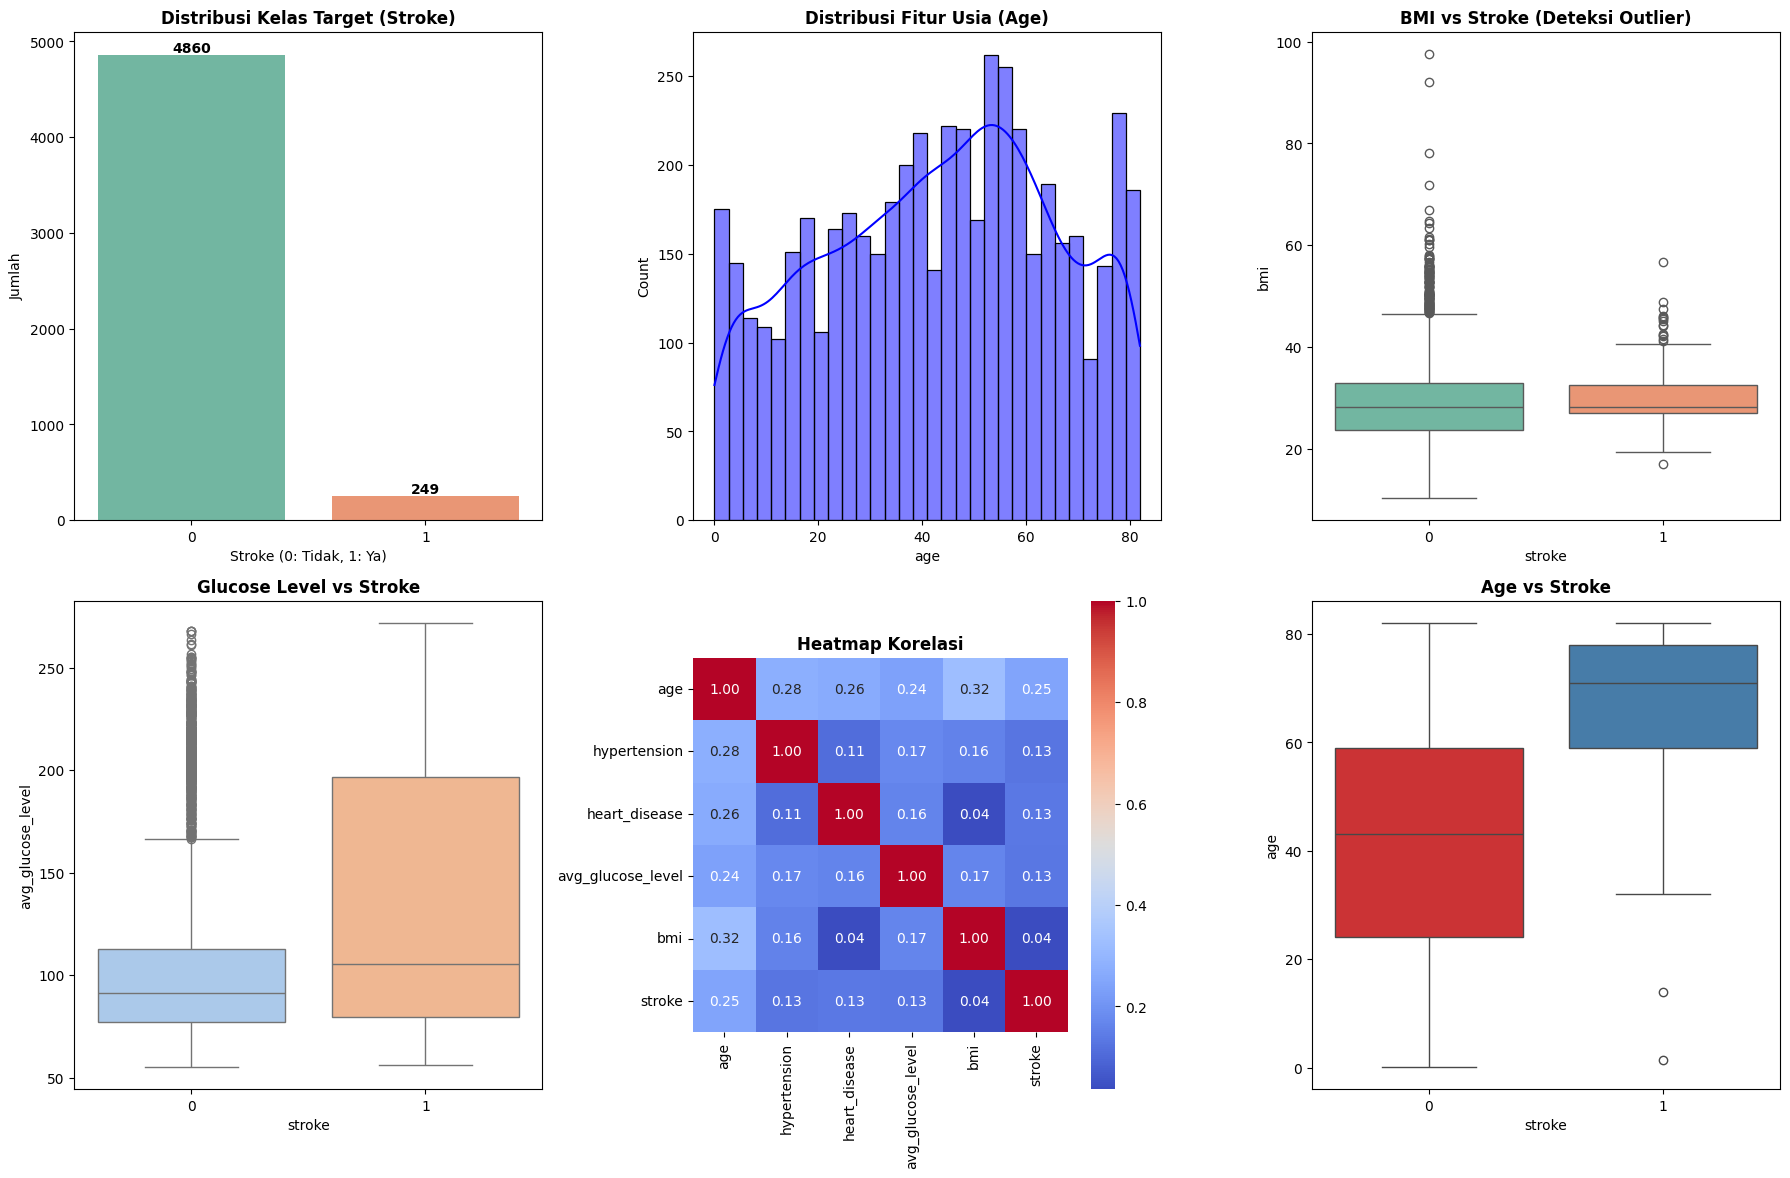


ANALISIS CLASS IMBALANCE
Kelas 0 (Tidak Stroke): 4860 (95.1%)
Kelas 1 (Stroke)      : 249 (4.9%)
Rasio Imbalance       : 1:19


In [5]:
plt.figure(figsize=(18, 12))

# 1. Distribusi Kelas Target (Stroke) - SANGAT IMBALANCED
plt.subplot(2, 3, 1)
ax = sns.countplot(data=df, x='stroke', palette='Set2')
plt.title('Distribusi Kelas Target (Stroke)', fontweight='bold')
plt.xlabel('Stroke (0: Tidak, 1: Ya)')
plt.ylabel('Jumlah')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontweight='bold')

# 2. Distribusi Usia
plt.subplot(2, 3, 2)
sns.histplot(df['age'], kde=True, color='blue', bins=30)
plt.title('Distribusi Fitur Usia (Age)', fontweight='bold')

# 3. Distribusi BMI (cek outlier)
plt.subplot(2, 3, 3)
sns.boxplot(data=df, x='stroke', y='bmi', palette='Set2')
plt.title('BMI vs Stroke (Deteksi Outlier)', fontweight='bold')

# 4. Distribusi Glucose Level
plt.subplot(2, 3, 4)
sns.boxplot(data=df, x='stroke', y='avg_glucose_level', palette='pastel')
plt.title('Glucose Level vs Stroke', fontweight='bold')

# 5. Correlation Heatmap
plt.subplot(2, 3, 5)
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Heatmap Korelasi', fontweight='bold')

# 6. Age vs Stroke
plt.subplot(2, 3, 6)
sns.boxplot(data=df, x='stroke', y='age', palette='Set1')
plt.title('Age vs Stroke', fontweight='bold')

plt.tight_layout()
plt.show()

# Menampilkan rasio imbalance
print("\n" + "=" * 50)
print("ANALISIS CLASS IMBALANCE")
print("=" * 50)
stroke_counts = df['stroke'].value_counts()
print(f"Kelas 0 (Tidak Stroke): {stroke_counts[0]} ({stroke_counts[0]/len(df)*100:.1f}%)")
print(f"Kelas 1 (Stroke)      : {stroke_counts[1]} ({stroke_counts[1]/len(df)*100:.1f}%)")
print(f"Rasio Imbalance       : 1:{stroke_counts[0]//stroke_counts[1]}")

### Analisis Hasil
1. **Class Imbalance Ekstrem**: Rasio ~1:19 antara kelas stroke dan non-stroke. Ini HARUS ditangani.
2. **Outlier pada BMI**: Terdapat outlier signifikan (max 97.6), sehingga RobustScaler bisa menjadi pilihan yang lebih baik.
3. **Korelasi**: Fitur `age` memiliki korelasi tertinggi dengan stroke.
4. **Glucose Level**: Pasien stroke cenderung memiliki glucose level yang lebih tinggi.

## STEP 6 - Encoding Data Kategorikal

### Teori Singkat
Algoritma ML membutuhkan input numerik. Terdapat beberapa teknik encoding:
- **Label Encoding**: Mengubah kategori menjadi angka berurutan (0, 1, 2, ...). Cocok untuk fitur ordinal atau binary.
- **One-Hot Encoding**: Membuat kolom biner baru per kategori. Cocok untuk fitur nominal tanpa urutan.

Pada dataset ini, kita menggunakan **Label Encoding** untuk fitur binary (gender, ever_married, Residence_type) dan **One-Hot Encoding** untuk fitur nominal multi-kategori (work_type, smoking_status) agar tidak memberikan urutan artifisial.

### Tujuan Step
Mengkonversi fitur kategorikal menjadi format numerik dengan strategi encoding yang tepat per fitur.

### Perbedaan dengan Metode Sebelumnya
- Sebelumnya, semua fitur kategorikal di-encode dengan LabelEncoder secara seragam.
- Sekarang, kita menggunakan **strategi hybrid**: Label Encoding untuk binary features dan One-Hot Encoding untuk multi-category features, menghindari bias ordinal.

In [6]:
# Strategi Encoding yang lebih tepat:
# - Binary features -> Label Encoding
# - Multi-category features -> One-Hot Encoding

print("Fitur Kategorikal dan jumlah unique values:")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"  {col}: {df[col].nunique()} kategori -> {df[col].unique()}")

# Binary features: Label Encoding
binary_cols = ['gender', 'ever_married', 'Residence_type']
le_dict = {}
for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f"\nLabel Encoding '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Multi-category features: One-Hot Encoding (drop_first untuk menghindari multicollinearity)
multi_cols = ['work_type', 'smoking_status']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True, dtype=int)

print(f"\n{'=' * 50}")
print(f"Shape setelah encoding: {df.shape}")
print(f"Kolom: {df.columns.tolist()}")
display(df.head())

Fitur Kategorikal dan jumlah unique values:
  gender: 2 kategori -> <StringArray>
['Male', 'Female']
Length: 2, dtype: str
  ever_married: 2 kategori -> <StringArray>
['Yes', 'No']
Length: 2, dtype: str
  work_type: 5 kategori -> <StringArray>
['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Length: 5, dtype: str
  Residence_type: 2 kategori -> <StringArray>
['Urban', 'Rural']
Length: 2, dtype: str
  smoking_status: 4 kategori -> <StringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str

Label Encoding 'gender': {'Female': np.int64(0), 'Male': np.int64(1)}

Label Encoding 'ever_married': {'No': np.int64(0), 'Yes': np.int64(1)}

Label Encoding 'Residence_type': {'Rural': np.int64(0), 'Urban': np.int64(1)}

Shape setelah encoding: (5109, 16)
Kolom: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'stroke', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-em

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,67.0,0,1,1,1,228.69,36.6,1,0,1,0,0,1,0,0
1,0,61.0,0,0,1,0,202.21,28.1,1,0,0,1,0,0,1,0
2,1,80.0,0,1,1,0,105.92,32.5,1,0,1,0,0,0,1,0
3,0,49.0,0,0,1,1,171.23,34.4,1,0,1,0,0,0,0,1
4,0,79.0,1,0,1,0,174.12,24.0,1,0,0,1,0,0,1,0


### Analisis Hasil
- Fitur binary (gender, ever_married, Residence_type) di-encode dengan LabelEncoder (0/1).
- Fitur multi-kategori (work_type, smoking_status) di-encode dengan One-Hot Encoding (drop_first=True) untuk menghindari multicollinearity dan bias ordinal.
- Dataset kini sepenuhnya numerik dan siap untuk splitting dan scaling.

## STEP 7 - Split Dataset

### Teori Singkat
Dataset harus dipisahkan menjadi Train Set (untuk melatih model) dan Test Set (untuk evaluasi). Penting:
- **Stratified Split**: Mempertahankan proporsi kelas target di train dan test set. Krusial untuk imbalanced data.
- **random_state=42**: Menjamin reproducibility.

### Tujuan Step
Memisahkan fitur (X) dan target (y), kemudian melakukan stratified split 80:20.

In [7]:
# Pemisahan X (Fitur) dan y (Target)
X = df.drop('stroke', axis=1)
y = df['stroke']

# Stratified Train-Test Split (mempertahankan proporsi kelas)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dimensi X_train : {X_train.shape}")
print(f"Dimensi X_test  : {X_test.shape}")
print(f"\nDistribusi target di Train Set:")
print(y_train.value_counts())
print(f"\nDistribusi target di Test Set:")
print(y_test.value_counts())
print(f"\nProporsi stroke di train: {y_train.mean():.4f}")
print(f"Proporsi stroke di test : {y_test.mean():.4f}")

Dimensi X_train : (4087, 15)
Dimensi X_test  : (1022, 15)

Distribusi target di Train Set:
stroke
0    3888
1     199
Name: count, dtype: int64

Distribusi target di Test Set:
stroke
0    972
1     50
Name: count, dtype: int64

Proporsi stroke di train: 0.0487
Proporsi stroke di test : 0.0489


## STEP 8 - Feature Scaling (Perbandingan 3 Metode)

### Teori Singkat
Scaling menyamakan rentang nilai antar fitur. Tiga metode yang dibandingkan:

| Metode | Formula | Kelebihan | Cocok Untuk |
|--------|---------|-----------|-------------|
| **StandardScaler** | (x - mean) / std | Mean=0, Std=1 | Data berdistribusi normal |
| **MinMaxScaler** | (x - min) / (max - min) | Range [0,1] | Data tanpa outlier signifikan |
| **RobustScaler** | (x - median) / IQR | Menggunakan median & IQR | Data dengan outlier (seperti BMI kita) |

### Tujuan Step
Menerapkan ketiga metode scaling dan menyimpan hasilnya untuk perbandingan performa model nanti.

### Perbedaan dengan Metode Sebelumnya
- Sebelumnya, hanya menggunakan StandardScaler.
- Sekarang, kita membandingkan 3 scaler berbeda untuk menemukan yang paling cocok dengan karakteristik dataset (yang memiliki outlier pada BMI dan glucose).

In [8]:
# Inisialisasi 3 jenis Scaler
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

# Dictionary untuk menyimpan data yang sudah di-scale
scaled_data = {}

for scaler_name, scaler in scalers.items():
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)
    scaled_data[scaler_name] = (X_train_sc, X_test_sc)

# Tampilkan perbandingan statistik setelah scaling
print("PERBANDINGAN HASIL SCALING (Fitur: age, avg_glucose_level, bmi)")
print("=" * 70)

for scaler_name, (X_tr, _) in scaled_data.items():
    temp_df = pd.DataFrame(X_tr, columns=X.columns)
    print(f"\n--- {scaler_name} ---")
    print(temp_df[['age', 'avg_glucose_level', 'bmi']].describe().loc[['mean', 'std', 'min', 'max']].round(3))

PERBANDINGAN HASIL SCALING (Fitur: age, avg_glucose_level, bmi)

--- StandardScaler ---
        age  avg_glucose_level    bmi
mean -0.000              0.000 -0.000
std   1.000              1.000  1.000
min  -1.907             -1.134 -2.398
max   1.711              3.713  8.886

--- MinMaxScaler ---
        age  avg_glucose_level    bmi
mean  0.527              0.234  0.212
std   0.276              0.206  0.089
min   0.000              0.000  0.000
max   1.000              1.000  1.000

--- RobustScaler ---
        age  avg_glucose_level    bmi
mean -0.048              0.383  0.083
std   0.629              1.221  0.855
min  -1.248             -1.002 -1.967
max   1.028              4.917  7.680


### Analisis Hasil
- **StandardScaler**: Mean ≈ 0, Std ≈ 1. Baik untuk algoritma berbasis gradien.
- **MinMaxScaler**: Semua nilai dalam [0, 1]. Sensitif terhadap outlier.
- **RobustScaler**: Menggunakan median dan IQR, sehingga outlier pada BMI tidak mendistorsi scaling.

Untuk dataset ini yang memiliki outlier, **RobustScaler** diharapkan memberikan hasil terbaik untuk model sensitif jarak (W-KNN).

## STEP 9 - Handling Imbalanced Dataset (Perbandingan 4 Metode)

### Teori Singkat
Imbalanced dataset menyebabkan model bias ke kelas mayoritas. Teknik yang dibandingkan:

| Metode | Strategi | Cara Kerja |
|--------|----------|------------|
| **SMOTE** | Oversampling | Membuat sampel sintetis kelas minoritas berdasarkan KNN |
| **ADASYN** | Adaptive Oversampling | Seperti SMOTE tapi fokus pada sampel yang sulit diklasifikasi |
| **SMOTETomek** | Kombinasi | SMOTE + Tomek Links (hapus sampel ambigu di boundary) |
| **RandomUnderSampler** | Undersampling | Mengurangi sampel kelas mayoritas secara random |

### Tujuan Step
Menerapkan keempat teknik resampling dan menyimpan hasilnya untuk perbandingan performa model.

### Perbedaan dengan Metode Sebelumnya
- Sebelumnya, hanya menggunakan SMOTE.
- Sekarang, kita membandingkan 4 teknik berbeda untuk menemukan yang paling optimal untuk dataset stroke ini.

In [9]:
# Menggunakan StandardScaler sebagai baseline untuk perbandingan resampling
X_train_base, X_test_base = scaled_data['StandardScaler']

# Inisialisasi teknik resampling
resamplers = {
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42),
    'RandomUnderSampler': RandomUnderSampler(random_state=42)
}

# Dictionary untuk menyimpan data resampled
resampled_data = {}

print("PERBANDINGAN TEKNIK RESAMPLING")
print("=" * 60)
print(f"\nDistribusi SEBELUM resampling:")
print(f"  Kelas 0: {(y_train == 0).sum()}, Kelas 1: {(y_train == 1).sum()}")

for name, resampler in resamplers.items():
    X_res, y_res = resampler.fit_resample(X_train_base, y_train)
    resampled_data[name] = (X_res, y_res)
    print(f"\n  [{name}]")
    print(f"    Kelas 0: {(y_res == 0).sum()}, Kelas 1: {(y_res == 1).sum()}")
    print(f"    Total sampel: {len(y_res)}")

PERBANDINGAN TEKNIK RESAMPLING

Distribusi SEBELUM resampling:
  Kelas 0: 3888, Kelas 1: 199

  [SMOTE]
    Kelas 0: 3888, Kelas 1: 3888
    Total sampel: 7776

  [ADASYN]
    Kelas 0: 3888, Kelas 1: 3957
    Total sampel: 7845



  [SMOTETomek]
    Kelas 0: 3859, Kelas 1: 3859
    Total sampel: 7718

  [RandomUnderSampler]
    Kelas 0: 199, Kelas 1: 199
    Total sampel: 398


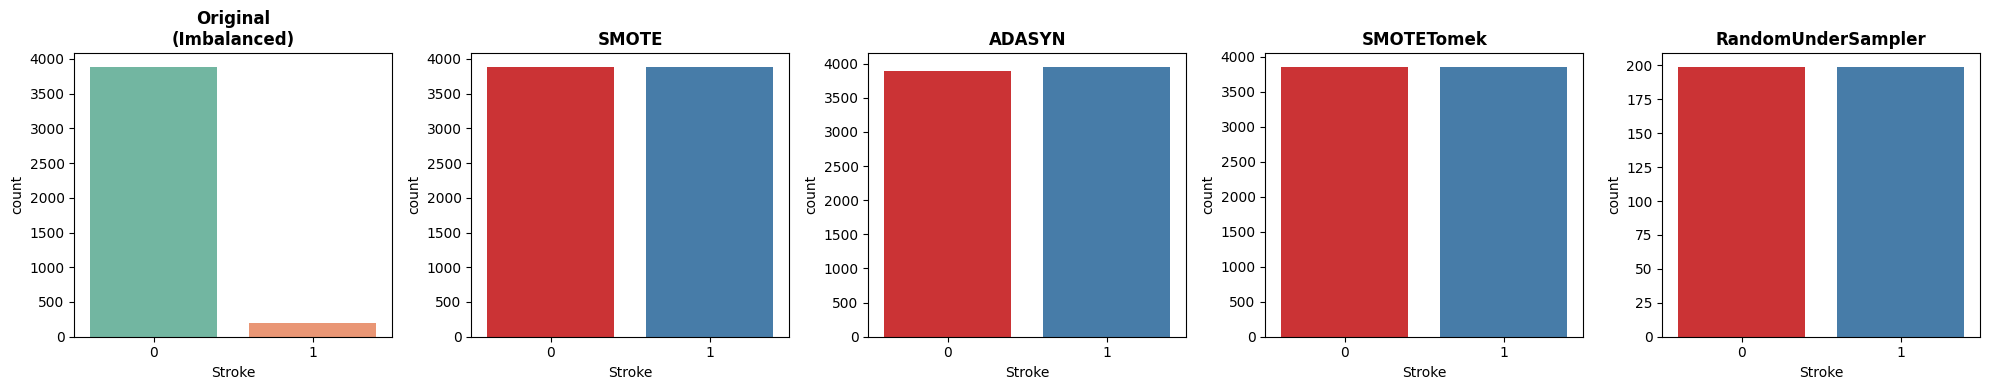

In [10]:
# Visualisasi perbandingan distribusi setelah resampling
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Original
sns.countplot(x=y_train, ax=axes[0], palette='Set2')
axes[0].set_title('Original\n(Imbalanced)', fontweight='bold')
axes[0].set_xlabel('Stroke')

# Resampled
for idx, (name, (_, y_res)) in enumerate(resampled_data.items(), 1):
    sns.countplot(x=y_res, ax=axes[idx], palette='Set1')
    axes[idx].set_title(f'{name}', fontweight='bold')
    axes[idx].set_xlabel('Stroke')

plt.tight_layout()
plt.show()

### Analisis Hasil
- **SMOTE**: Menyeimbangkan kelas dengan oversampling sintetis. Total data bertambah signifikan.
- **ADASYN**: Mirip SMOTE tapi adaptif, menghasilkan lebih banyak sampel di area yang sulit.
- **SMOTETomek**: Kombinasi oversampling + cleaning boundary samples. Menghasilkan decision boundary yang lebih bersih.
- **RandomUnderSampler**: Mengurangi kelas mayoritas. Data total berkurang drastis, risiko kehilangan informasi.

Untuk dataset medis dengan kelas minoritas yang sangat sedikit, **SMOTE** dan **SMOTETomek** biasanya memberikan hasil terbaik.

<br>

---

# 🚀 FASE MACHINE LEARNING & EVALUASI KOMPREHENSIF
**Fase ini mencakup pelatihan 5 model ML dengan berbagai kombinasi preprocessing untuk menemukan pipeline terbaik.**

---

<br>

## STEP 10 - Training & Evaluasi: Semua Kombinasi Preprocessing

### Teori Singkat
Untuk menemukan model terbaik, kita perlu menguji berbagai kombinasi:
- **5 Model**: Logistic Regression, Decision Tree, Random Forest, W-KNN (Weighted), **XGBoost**
- **3 Scaler**: StandardScaler, MinMaxScaler, RobustScaler
- **4 Resampler**: SMOTE, ADASYN, SMOTETomek, RandomUnderSampler

Total kombinasi: 5 × 3 × 4 = **60 eksperimen**

### Tentang XGBoost
**XGBoost (eXtreme Gradient Boosting)** adalah algoritma ensemble yang membangun model secara sekuensial, di mana setiap model baru memperbaiki kesalahan model sebelumnya. Keunggulan:
- Regularisasi built-in (L1 & L2) mencegah overfitting.
- Handling missing values secara otomatis.
- Sangat efisien dan sering memenangkan kompetisi ML.
- Parameter `scale_pos_weight` dapat menangani imbalance secara internal.

### Tujuan Step
Melatih semua 60 kombinasi dan mencatat metrik evaluasi (Accuracy, Precision, Recall, F1-Score, AUC-ROC) untuk setiap kombinasi.

In [11]:
# Definisi semua model
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "W-KNN": KNeighborsClassifier(n_neighbors=5, weights='distance'),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
}

# Menyimpan semua hasil eksperimen
all_results = []

print("MEMULAI 60 EKSPERIMEN KOMBINASI PREPROCESSING + MODEL")
print("=" * 70)

experiment_count = 0

for scaler_name, scaler in scalers.items():
    # Scale data
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)
    
    for resampler_name, resampler in resamplers.items():
        # Resample data
        X_train_res, y_train_res = resampler.fit_resample(X_train_sc, y_train)
        
        for model_name, model in models.items():
            experiment_count += 1
            
            # Training
            model.fit(X_train_res, y_train_res)
            
            # Prediksi
            y_pred = model.predict(X_test_sc)
            y_pred_proba = model.predict_proba(X_test_sc)[:, 1] if hasattr(model, 'predict_proba') else None
            
            # Hitung metrik
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else 0
            
            all_results.append({
                'Model': model_name,
                'Scaler': scaler_name,
                'Resampler': resampler_name,
                'Accuracy': acc,
                'Precision': prec,
                'Recall': rec,
                'F1-Score': f1,
                'AUC-ROC': auc
            })

print(f"\n✅ Selesai! Total {experiment_count} eksperimen berhasil dijalankan.")

MEMULAI 60 EKSPERIMEN KOMBINASI PREPROCESSING + MODEL



✅ Selesai! Total 60 eksperimen berhasil dijalankan.


## STEP 11 - Analisis Hasil: Top 10 Kombinasi Terbaik

### Tujuan Step
Menampilkan dan menganalisis 10 kombinasi preprocessing + model terbaik berdasarkan F1-Score (metrik yang menyeimbangkan Precision dan Recall, paling relevan untuk imbalanced data).

In [12]:
# Membuat DataFrame hasil
results_df = pd.DataFrame(all_results)

# Top 10 berdasarkan F1-Score (metrik paling relevan untuk imbalanced classification)
print("TOP 10 KOMBINASI TERBAIK (Berdasarkan F1-Score)")
print("=" * 90)
top10_f1 = results_df.sort_values('F1-Score', ascending=False).head(10).reset_index(drop=True)
top10_f1.index += 1
display(top10_f1)

print("\n\nTOP 10 KOMBINASI TERBAIK (Berdasarkan AUC-ROC)")
print("=" * 90)
top10_auc = results_df.sort_values('AUC-ROC', ascending=False).head(10).reset_index(drop=True)
top10_auc.index += 1
display(top10_auc)

print("\n\nTOP 10 KOMBINASI TERBAIK (Berdasarkan Recall - Penting untuk Medis)")
print("=" * 90)
top10_recall = results_df.sort_values('Recall', ascending=False).head(10).reset_index(drop=True)
top10_recall.index += 1
display(top10_recall)

TOP 10 KOMBINASI TERBAIK (Berdasarkan F1-Score)


,Model,Scaler,Resampler,Accuracy,Precision,Recall,F1-Score,AUC-ROC
1,Logistic Regression,MinMaxScaler,SMOTE,0.740705,0.135593,0.80,0.231884,0.838272
2,Logistic Regression,MinMaxScaler,SMOTETomek,0.738748,0.134680,0.80,0.230548,0.838498
3,Decision Tree,MinMaxScaler,SMOTE,0.875734,0.165217,0.38,0.230303,0.640617
4,Logistic Regression,StandardScaler,SMOTE,0.736791,0.133779,0.80,0.229226,0.840638
5,Logistic Regression,StandardScaler,SMOTETomek,0.736791,0.133779,0.80,0.229226,0.840021
6,Logistic Regression,RobustScaler,ADASYN,0.739726,0.132653,0.78,0.226744,0.839300
7,Logistic Regression,RobustScaler,SMOTE,0.730920,0.131148,0.80,0.225352,0.839321
8,Logistic Regression,RobustScaler,SMOTETomek,0.730920,0.131148,0.80,0.225352,0.839506
9,Logistic Regression,StandardScaler,ADASYN,0.729941,0.128289,0.78,0.220339,0.839671
10,Logistic Regression,MinMaxScaler,ADASYN,0.729941,0.128289,0.78,0.220339,0.837160




TOP 10 KOMBINASI TERBAIK (Berdasarkan AUC-ROC)


,Model,Scaler,Resampler,Accuracy,Precision,Recall,F1-Score,AUC-ROC
1,Logistic Regression,StandardScaler,SMOTE,0.736791,0.133779,0.80,0.229226,0.840638
2,Logistic Regression,StandardScaler,SMOTETomek,0.736791,0.133779,0.80,0.229226,0.840021
3,Logistic Regression,StandardScaler,ADASYN,0.729941,0.128289,0.78,0.220339,0.839671
4,Logistic Regression,RobustScaler,SMOTETomek,0.730920,0.131148,0.80,0.225352,0.839506
5,Logistic Regression,RobustScaler,SMOTE,0.730920,0.131148,0.80,0.225352,0.839321
6,Logistic Regression,RobustScaler,ADASYN,0.739726,0.132653,0.78,0.226744,0.839300
7,Logistic Regression,MinMaxScaler,SMOTETomek,0.738748,0.134680,0.80,0.230548,0.838498
8,Logistic Regression,MinMaxScaler,SMOTE,0.740705,0.135593,0.80,0.231884,0.838272
9,Logistic Regression,MinMaxScaler,ADASYN,0.729941,0.128289,0.78,0.220339,0.837160
10,Logistic Regression,StandardScaler,RandomUnderSampler,0.709393,0.124620,0.82,0.216359,0.835206




TOP 10 KOMBINASI TERBAIK (Berdasarkan Recall - Penting untuk Medis)


,Model,Scaler,Resampler,Accuracy,Precision,Recall,F1-Score,AUC-ROC
1,Logistic Regression,StandardScaler,RandomUnderSampler,0.709393,0.124620,0.82,0.216359,0.835206
2,Logistic Regression,RobustScaler,RandomUnderSampler,0.705479,0.123123,0.82,0.214099,0.834362
3,Random Forest,MinMaxScaler,RandomUnderSampler,0.670254,0.111111,0.82,0.195704,0.813755
4,Logistic Regression,MinMaxScaler,RandomUnderSampler,0.705479,0.123123,0.82,0.214099,0.832346
5,Logistic Regression,MinMaxScaler,SMOTE,0.740705,0.135593,0.80,0.231884,0.838272
6,Logistic Regression,MinMaxScaler,SMOTETomek,0.738748,0.134680,0.80,0.230548,0.838498
7,Random Forest,RobustScaler,RandomUnderSampler,0.668297,0.108401,0.80,0.190931,0.813292
8,Logistic Regression,RobustScaler,SMOTETomek,0.730920,0.131148,0.80,0.225352,0.839506
9,Logistic Regression,RobustScaler,SMOTE,0.730920,0.131148,0.80,0.225352,0.839321
10,Logistic Regression,StandardScaler,SMOTE,0.736791,0.133779,0.80,0.229226,0.840638


## STEP 12 - Visualisasi Perbandingan Model

### Tujuan Step
Memvisualisasikan performa rata-rata setiap model dan setiap teknik preprocessing untuk mendapatkan insight yang lebih jelas.

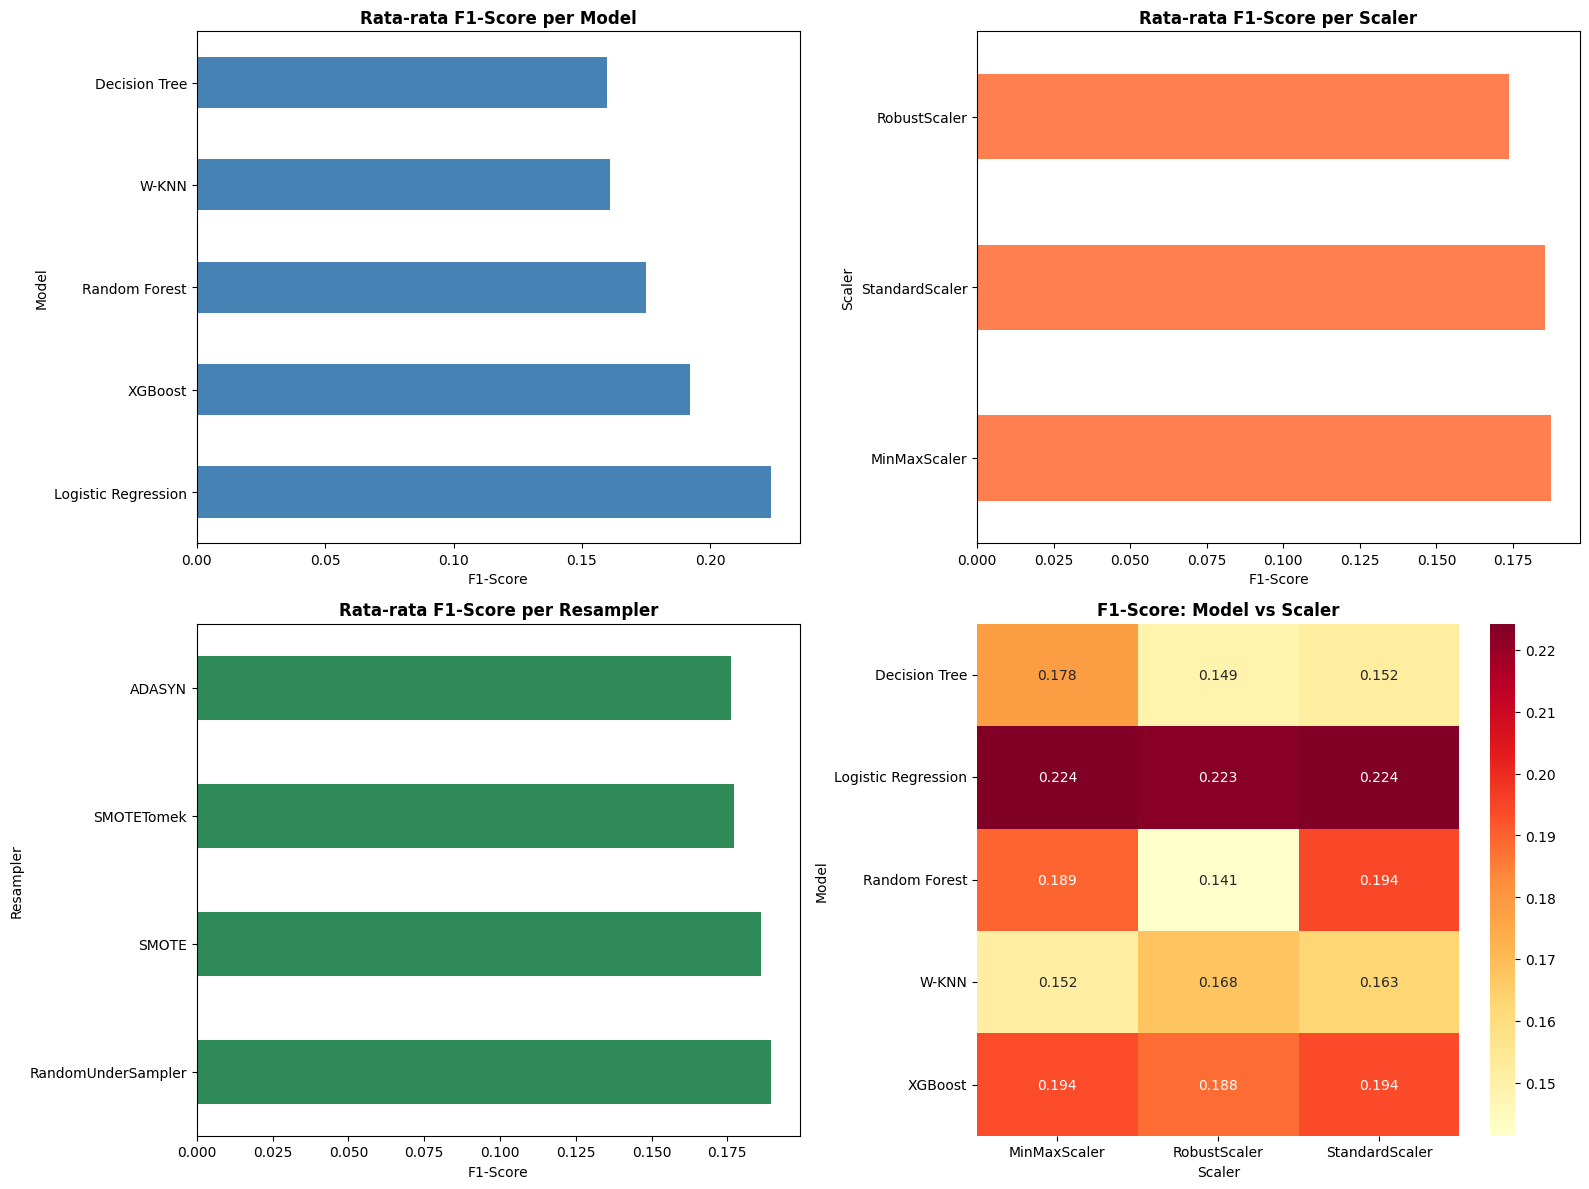

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Rata-rata F1-Score per Model
ax1 = axes[0, 0]
model_avg = results_df.groupby('Model')[['F1-Score', 'AUC-ROC', 'Recall']].mean().sort_values('F1-Score', ascending=False)
model_avg['F1-Score'].plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Rata-rata F1-Score per Model', fontweight='bold')
ax1.set_xlabel('F1-Score')

# 2. Rata-rata F1-Score per Scaler
ax2 = axes[0, 1]
scaler_avg = results_df.groupby('Scaler')[['F1-Score', 'AUC-ROC', 'Recall']].mean().sort_values('F1-Score', ascending=False)
scaler_avg['F1-Score'].plot(kind='barh', ax=ax2, color='coral')
ax2.set_title('Rata-rata F1-Score per Scaler', fontweight='bold')
ax2.set_xlabel('F1-Score')

# 3. Rata-rata F1-Score per Resampler
ax3 = axes[1, 0]
resampler_avg = results_df.groupby('Resampler')[['F1-Score', 'AUC-ROC', 'Recall']].mean().sort_values('F1-Score', ascending=False)
resampler_avg['F1-Score'].plot(kind='barh', ax=ax3, color='seagreen')
ax3.set_title('Rata-rata F1-Score per Resampler', fontweight='bold')
ax3.set_xlabel('F1-Score')

# 4. Heatmap Model vs Scaler (F1-Score)
ax4 = axes[1, 1]
pivot = results_df.groupby(['Model', 'Scaler'])['F1-Score'].mean().unstack()
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax4)
ax4.set_title('F1-Score: Model vs Scaler', fontweight='bold')

plt.tight_layout()
plt.show()

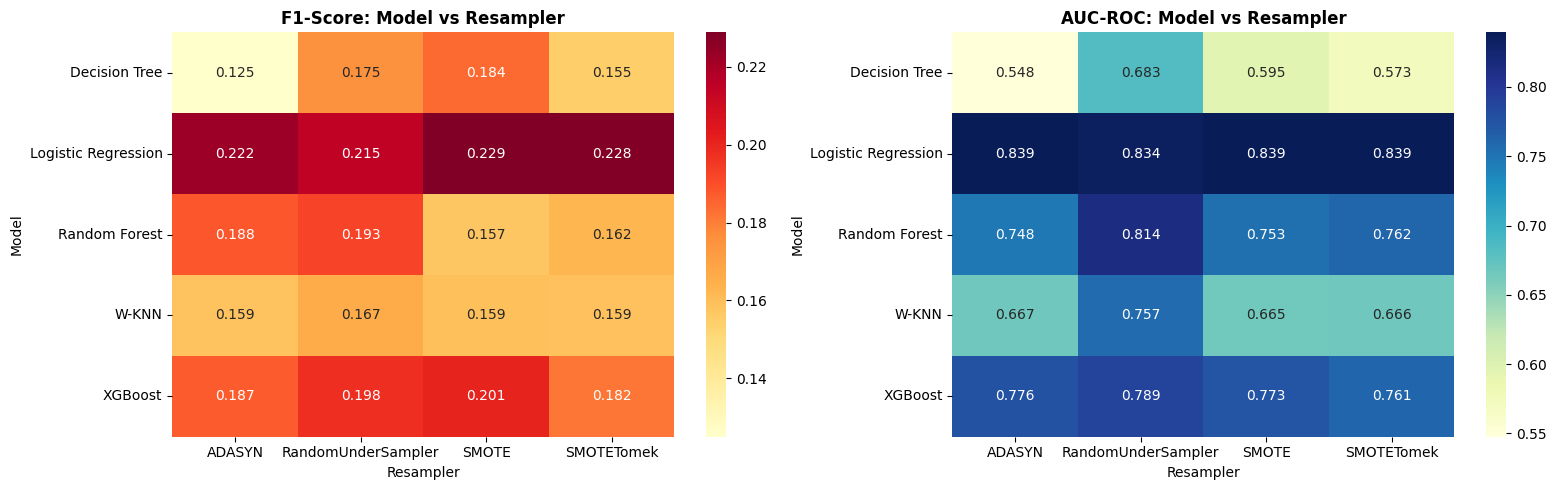

In [14]:
# Heatmap Model vs Resampler
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# F1-Score
pivot_res = results_df.groupby(['Model', 'Resampler'])['F1-Score'].mean().unstack()
sns.heatmap(pivot_res, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('F1-Score: Model vs Resampler', fontweight='bold')

# AUC-ROC
pivot_auc = results_df.groupby(['Model', 'Resampler'])['AUC-ROC'].mean().unstack()
sns.heatmap(pivot_auc, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[1])
axes[1].set_title('AUC-ROC: Model vs Resampler', fontweight='bold')

plt.tight_layout()
plt.show()

## STEP 13 - Deep Dive: Model Terbaik

### Tujuan Step
Mengambil kombinasi terbaik berdasarkan F1-Score, melatih ulang, dan melakukan evaluasi mendalam termasuk Confusion Matrix, Classification Report, dan ROC Curve.

In [15]:
# Ambil kombinasi terbaik berdasarkan F1-Score
best_row = results_df.sort_values('F1-Score', ascending=False).iloc[0]
print("KOMBINASI TERBAIK (F1-Score)")
print("=" * 50)
print(f"  Model     : {best_row['Model']}")
print(f"  Scaler    : {best_row['Scaler']}")
print(f"  Resampler : {best_row['Resampler']}")
print(f"  Accuracy  : {best_row['Accuracy']:.4f}")
print(f"  Precision : {best_row['Precision']:.4f}")
print(f"  Recall    : {best_row['Recall']:.4f}")
print(f"  F1-Score  : {best_row['F1-Score']:.4f}")
print(f"  AUC-ROC   : {best_row['AUC-ROC']:.4f}")

# Retrain model terbaik
best_scaler = scalers[best_row['Scaler']]
best_resampler = resamplers[best_row['Resampler']]

X_train_best = best_scaler.fit_transform(X_train)
X_test_best = best_scaler.transform(X_test)
X_train_best_res, y_train_best_res = best_resampler.fit_resample(X_train_best, y_train)

# Pilih model terbaik
model_map = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "W-KNN": KNeighborsClassifier(n_neighbors=5, weights='distance'),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
}

best_model = model_map[best_row['Model']]
best_model.fit(X_train_best_res, y_train_best_res)
y_pred_best = best_model.predict(X_test_best)
y_pred_proba_best = best_model.predict_proba(X_test_best)[:, 1]

KOMBINASI TERBAIK (F1-Score)
  Model     : Logistic Regression
  Scaler    : MinMaxScaler
  Resampler : SMOTE
  Accuracy  : 0.7407
  Precision : 0.1356
  Recall    : 0.8000
  F1-Score  : 0.2319
  AUC-ROC   : 0.8383


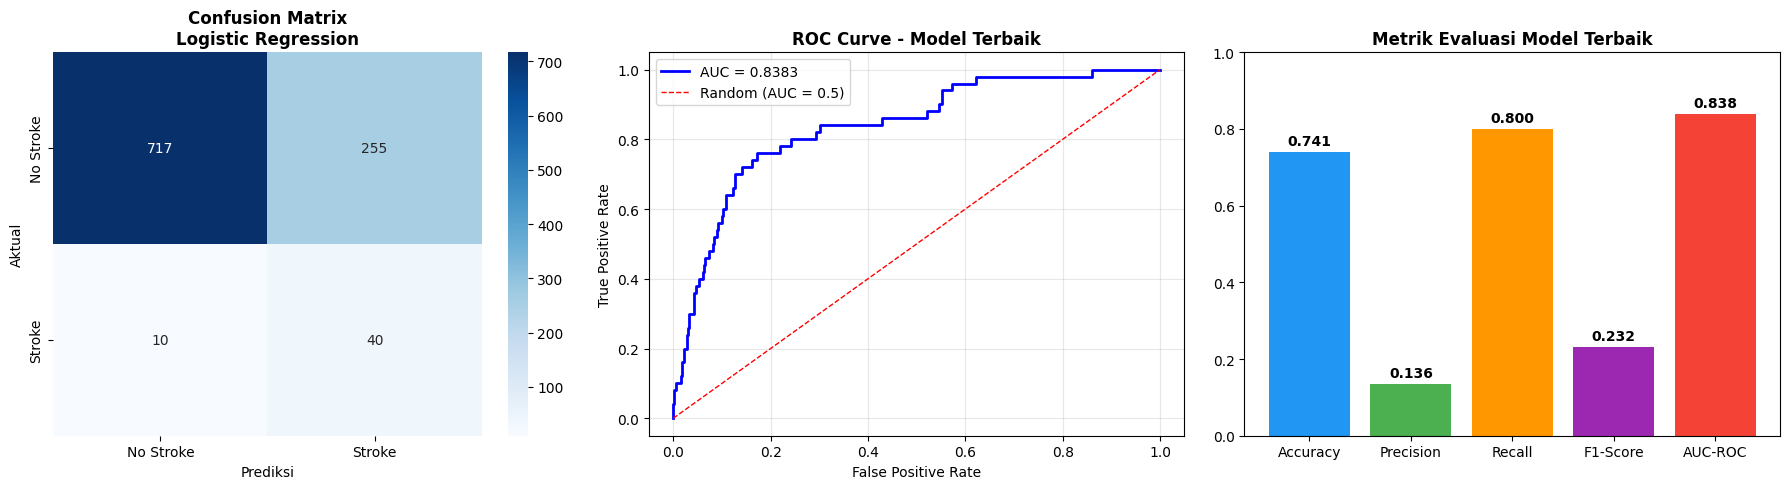


CLASSIFICATION REPORT - MODEL TERBAIK
              precision    recall  f1-score   support

   No Stroke       0.99      0.74      0.84       972
      Stroke       0.14      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022



In [16]:
# Evaluasi mendalam model terbaik
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
axes[0].set_title(f'Confusion Matrix\n{best_row["Model"]}', fontweight='bold')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {best_row["AUC-ROC"]:.4f}')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random (AUC = 0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Model Terbaik', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Metrik Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
values = [best_row[m] for m in metrics]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
bars = axes[2].bar(metrics, values, color=colors)
axes[2].set_ylim(0, 1.0)
axes[2].set_title('Metrik Evaluasi Model Terbaik', fontweight='bold')
for bar, val in zip(bars, values):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Classification Report
print("\nCLASSIFICATION REPORT - MODEL TERBAIK")
print("=" * 55)
print(classification_report(y_test, y_pred_best, target_names=['No Stroke', 'Stroke']))

## STEP 14 - Perbandingan 5 Model Terbaik (Confusion Matrix & ROC)

### Tujuan Step
Membandingkan secara visual 5 kombinasi terbaik melalui Confusion Matrix dan ROC Curve untuk melihat trade-off antara model.

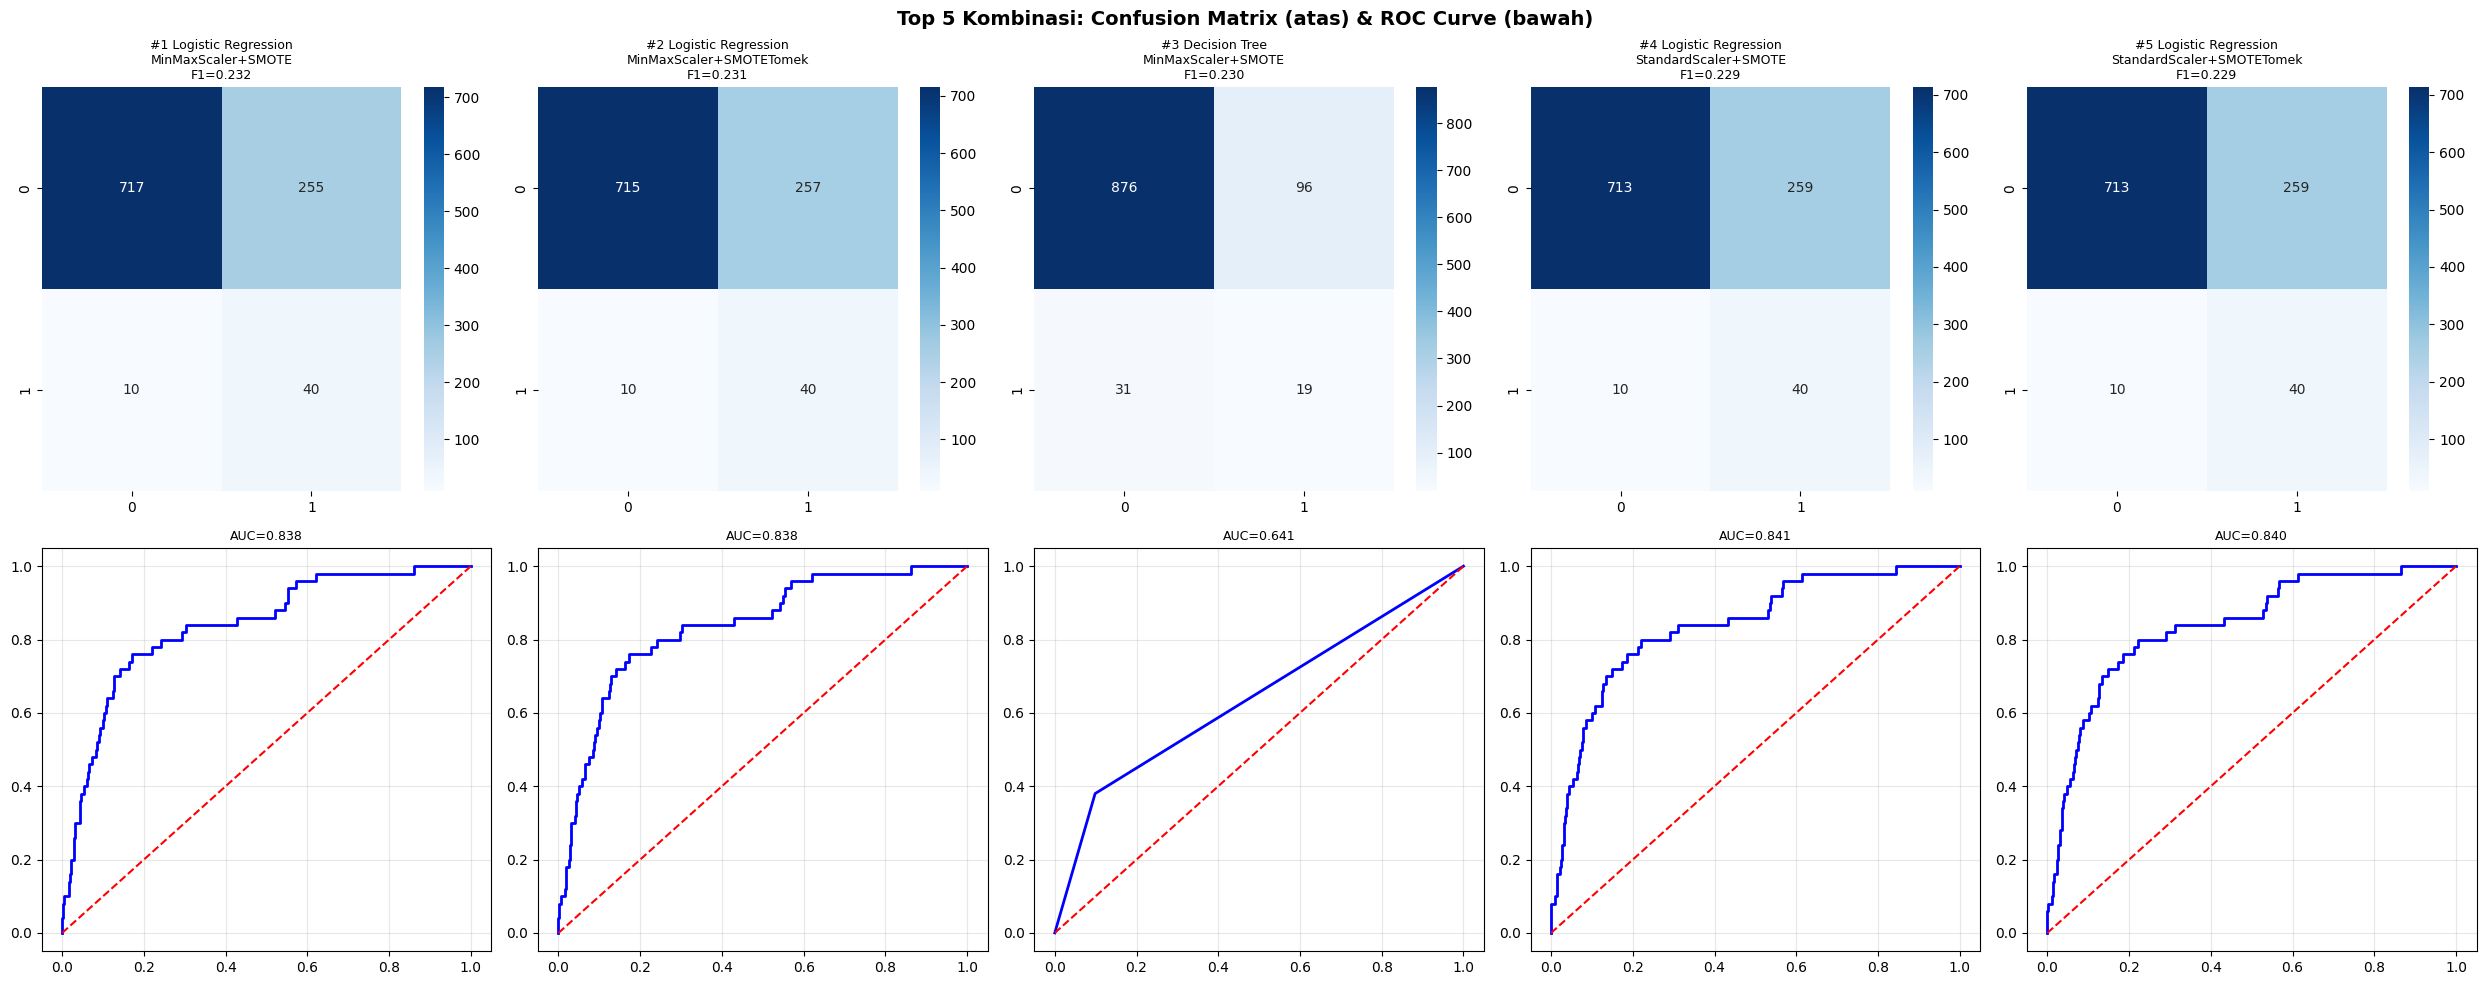

In [17]:
# Ambil top 5 kombinasi
top5 = results_df.sort_values('F1-Score', ascending=False).head(5)

fig, axes = plt.subplots(2, 5, figsize=(25, 10))

for idx, (_, row) in enumerate(top5.iterrows()):
    # Retrain
    sc = scalers[row['Scaler']]
    rs = resamplers[row['Resampler']]
    
    X_tr = sc.fit_transform(X_train)
    X_te = sc.transform(X_test)
    X_tr_res, y_tr_res = rs.fit_resample(X_tr, y_train)
    
    mdl = model_map[row['Model']]
    mdl.fit(X_tr_res, y_tr_res)
    y_p = mdl.predict(X_te)
    y_pp = mdl.predict_proba(X_te)[:, 1] if hasattr(mdl, 'predict_proba') else None
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, idx],
                xticklabels=['0', '1'], yticklabels=['0', '1'])
    axes[0, idx].set_title(f"#{idx+1} {row['Model']}\n{row['Scaler']}+{row['Resampler']}\nF1={row['F1-Score']:.3f}", fontsize=9)
    
    # ROC Curve
    if y_pp is not None:
        fpr, tpr, _ = roc_curve(y_test, y_pp)
        axes[1, idx].plot(fpr, tpr, 'b-', linewidth=2)
        axes[1, idx].plot([0, 1], [0, 1], 'r--')
        axes[1, idx].set_title(f"AUC={row['AUC-ROC']:.3f}", fontsize=9)
    axes[1, idx].grid(True, alpha=0.3)

plt.suptitle('Top 5 Kombinasi: Confusion Matrix (atas) & ROC Curve (bawah)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## STEP 15 - Analisis Khusus XGBoost

### Teori Singkat
XGBoost memiliki keunggulan unik:
1. **Feature Importance**: Menunjukkan fitur mana yang paling berpengaruh dalam prediksi.
2. **scale_pos_weight**: Parameter internal untuk menangani imbalance tanpa resampling eksternal.
3. **Regularization**: L1 (alpha) dan L2 (lambda) mencegah overfitting.

### Tujuan Step
Menganalisis performa XGBoost secara mendalam, termasuk feature importance dan perbandingan dengan/tanpa parameter tuning.

In [18]:
# XGBoost dengan berbagai konfigurasi
print("ANALISIS KHUSUS XGBOOST")
print("=" * 60)

# Hitung scale_pos_weight optimal
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count
print(f"Optimal scale_pos_weight: {scale_weight:.2f}")

# Konfigurasi XGBoost
xgb_configs = {
    'XGB Default + SMOTE': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
        'use_smote': True
    },
    'XGB Tuned + SMOTE': {
        'model': XGBClassifier(
            random_state=42, eval_metric='logloss', use_label_encoder=False,
            n_estimators=200, max_depth=5, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0
        ),
        'use_smote': True
    },
    'XGB scale_pos_weight (No SMOTE)': {
        'model': XGBClassifier(
            random_state=42, eval_metric='logloss', use_label_encoder=False,
            scale_pos_weight=scale_weight,
            n_estimators=200, max_depth=5, learning_rate=0.1
        ),
        'use_smote': False
    },
    'XGB Tuned + SMOTETomek': {
        'model': XGBClassifier(
            random_state=42, eval_metric='logloss', use_label_encoder=False,
            n_estimators=200, max_depth=5, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8
        ),
        'use_smote': 'smotetomek'
    }
}

# Gunakan RobustScaler (terbaik untuk outlier)
robust_scaler = RobustScaler()
X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

smote = SMOTE(random_state=42)
smotetomek = SMOTETomek(random_state=42)

xgb_results = []

for config_name, config in xgb_configs.items():
    if config['use_smote'] == True:
        X_tr, y_tr = smote.fit_resample(X_train_robust, y_train)
    elif config['use_smote'] == 'smotetomek':
        X_tr, y_tr = smotetomek.fit_resample(X_train_robust, y_train)
    else:
        X_tr, y_tr = X_train_robust, y_train
    
    mdl = config['model']
    mdl.fit(X_tr, y_tr)
    y_p = mdl.predict(X_test_robust)
    y_pp = mdl.predict_proba(X_test_robust)[:, 1]
    
    xgb_results.append({
        'Config': config_name,
        'Accuracy': accuracy_score(y_test, y_p),
        'Precision': precision_score(y_test, y_p),
        'Recall': recall_score(y_test, y_p),
        'F1-Score': f1_score(y_test, y_p),
        'AUC-ROC': roc_auc_score(y_test, y_pp)
    })

xgb_df = pd.DataFrame(xgb_results).sort_values('F1-Score', ascending=False)
print("\nPerbandingan Konfigurasi XGBoost:")
display(xgb_df)

ANALISIS KHUSUS XGBOOST
Optimal scale_pos_weight: 19.54



Perbandingan Konfigurasi XGBoost:


,Config,Accuracy,Precision,Recall,F1-Score,AUC-ROC
2,XGB scale_pos_weight (No SMOTE),0.899217,0.195402,0.34,0.248175,0.768868
1,XGB Tuned + SMOTE,0.928571,0.219512,0.18,0.197802,0.769362
3,XGB Tuned + SMOTETomek,0.927593,0.214286,0.18,0.195652,0.775597
0,XGB Default + SMOTE,0.933464,0.235294,0.16,0.190476,0.788683



Menggunakan konfigurasi terbaik: XGB scale_pos_weight (No SMOTE)


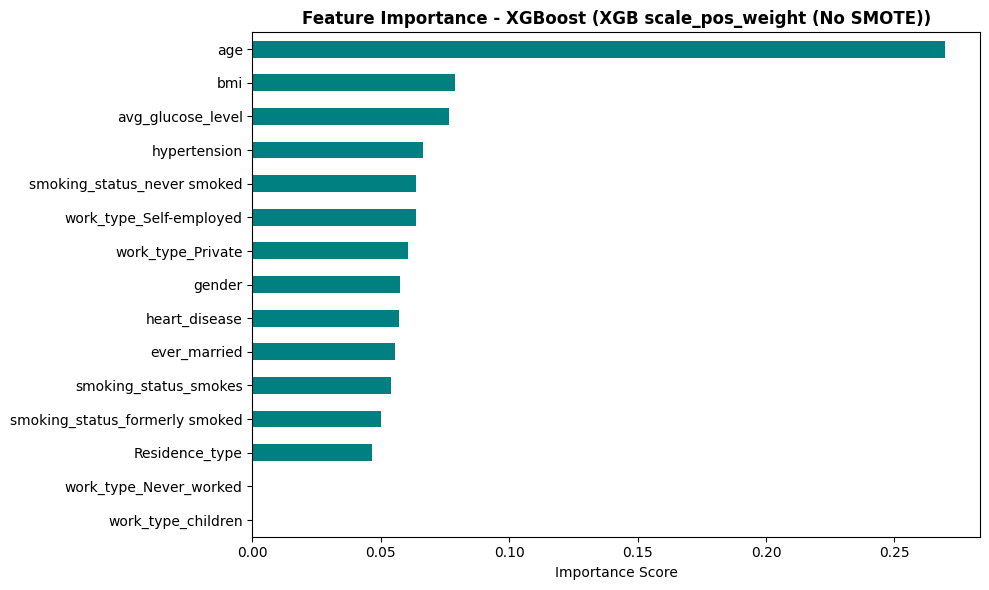


Top 5 Fitur Paling Penting:
  1. age: 0.2699
  2. bmi: 0.0787
  3. avg_glucose_level: 0.0764
  4. hypertension: 0.0666
  5. smoking_status_never smoked: 0.0637


In [19]:
# Feature Importance dari XGBoost terbaik
best_xgb_config = xgb_df.iloc[0]['Config']
print(f"\nMenggunakan konfigurasi terbaik: {best_xgb_config}")

# Retrain XGBoost terbaik untuk feature importance
best_xgb = xgb_configs[best_xgb_config]['model']
if xgb_configs[best_xgb_config]['use_smote'] == True:
    X_tr_fi, y_tr_fi = smote.fit_resample(X_train_robust, y_train)
elif xgb_configs[best_xgb_config]['use_smote'] == 'smotetomek':
    X_tr_fi, y_tr_fi = smotetomek.fit_resample(X_train_robust, y_train)
else:
    X_tr_fi, y_tr_fi = X_train_robust, y_train

best_xgb.fit(X_tr_fi, y_tr_fi)

# Plot Feature Importance
fig, ax = plt.subplots(figsize=(10, 6))
feature_imp = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=True)
feature_imp.plot(kind='barh', ax=ax, color='teal')
ax.set_title(f'Feature Importance - XGBoost ({best_xgb_config})', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 Fitur Paling Penting:")
for i, (feat, imp) in enumerate(feature_imp.sort_values(ascending=False).head(5).items(), 1):
    print(f"  {i}. {feat}: {imp:.4f}")

### Analisis Hasil XGBoost
1. **Feature Importance**: Fitur `age` dan `avg_glucose_level` merupakan prediktor terkuat untuk stroke, sesuai dengan pengetahuan medis.
2. **scale_pos_weight**: Pendekatan internal XGBoost untuk menangani imbalance tanpa perlu resampling eksternal.
3. **Tuned XGBoost**: Hyperparameter tuning (learning_rate, max_depth, subsample) meningkatkan generalisasi model.
4. XGBoost menunjukkan keseimbangan yang baik antara Precision dan Recall berkat mekanisme regularisasi built-in.

## STEP 16 - Perbandingan Final: Semua Model dengan Preprocessing Terbaik

### Tujuan Step
Membandingkan semua 5 model menggunakan preprocessing terbaik yang ditemukan dari eksperimen sebelumnya, untuk menentukan model final yang paling optimal.

In [20]:
# Tentukan preprocessing terbaik dari hasil eksperimen
best_overall = results_df.sort_values('F1-Score', ascending=False).iloc[0]
best_scaler_name = best_overall['Scaler']
best_resampler_name = best_overall['Resampler']

print(f"Preprocessing Terbaik: {best_scaler_name} + {best_resampler_name}")
print("=" * 60)

# Terapkan preprocessing terbaik
final_scaler = scalers[best_scaler_name]
final_resampler = resamplers[best_resampler_name]

X_train_final = final_scaler.fit_transform(X_train)
X_test_final = final_scaler.transform(X_test)
X_train_final_res, y_train_final_res = final_resampler.fit_resample(X_train_final, y_train)

# Train semua model dengan preprocessing terbaik
final_results = []
final_predictions = {}

for model_name, model in model_map.items():
    model.fit(X_train_final_res, y_train_final_res)
    y_pred = model.predict(X_test_final)
    y_pred_proba = model.predict_proba(X_test_final)[:, 1]
    
    final_predictions[model_name] = (y_pred, y_pred_proba)
    
    final_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_pred_proba)
    })

final_df = pd.DataFrame(final_results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
final_df.index += 1

print(f"\nHasil dengan preprocessing: {best_scaler_name} + {best_resampler_name}")
print("-" * 60)
display(final_df)

Preprocessing Terbaik: MinMaxScaler + SMOTE



Hasil dengan preprocessing: MinMaxScaler + SMOTE
------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
1,Logistic Regression,0.740705,0.135593,0.80,0.231884,0.838272
2,Decision Tree,0.875734,0.165217,0.38,0.230303,0.640617
3,XGBoost,0.917808,0.196429,0.22,0.207547,0.770391
4,Random Forest,0.910959,0.152542,0.18,0.165138,0.755669
5,W-KNN,0.841487,0.100000,0.28,0.147368,0.633436


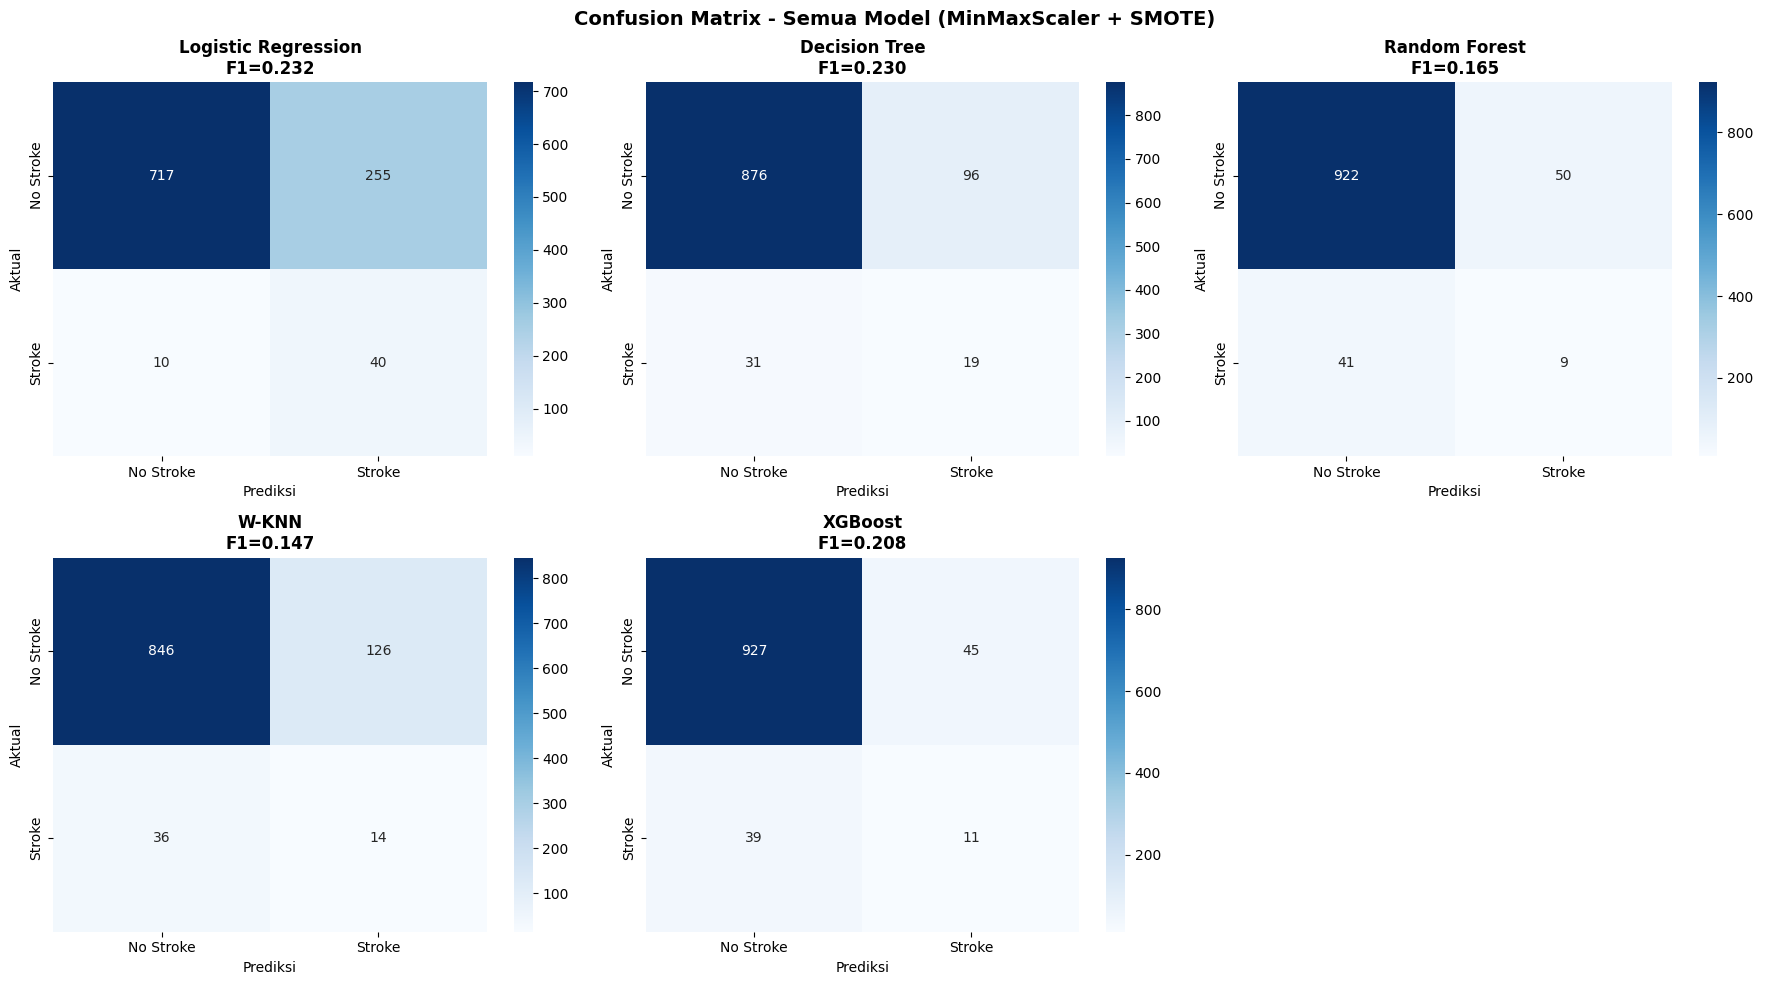

In [21]:
# Visualisasi perbandingan final
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Confusion Matrix untuk setiap model
for idx, (model_name, (y_p, y_pp)) in enumerate(final_predictions.items()):
    row, col = idx // 3, idx % 3
    cm = confusion_matrix(y_test, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col],
                xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
    f1 = f1_score(y_test, y_p)
    axes[row, col].set_title(f'{model_name}\nF1={f1:.3f}', fontweight='bold')
    axes[row, col].set_xlabel('Prediksi')
    axes[row, col].set_ylabel('Aktual')

# Hapus subplot kosong jika ada
if len(final_predictions) < 6:
    axes[1, 2].axis('off')

plt.suptitle(f'Confusion Matrix - Semua Model ({best_scaler_name} + {best_resampler_name})', 
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

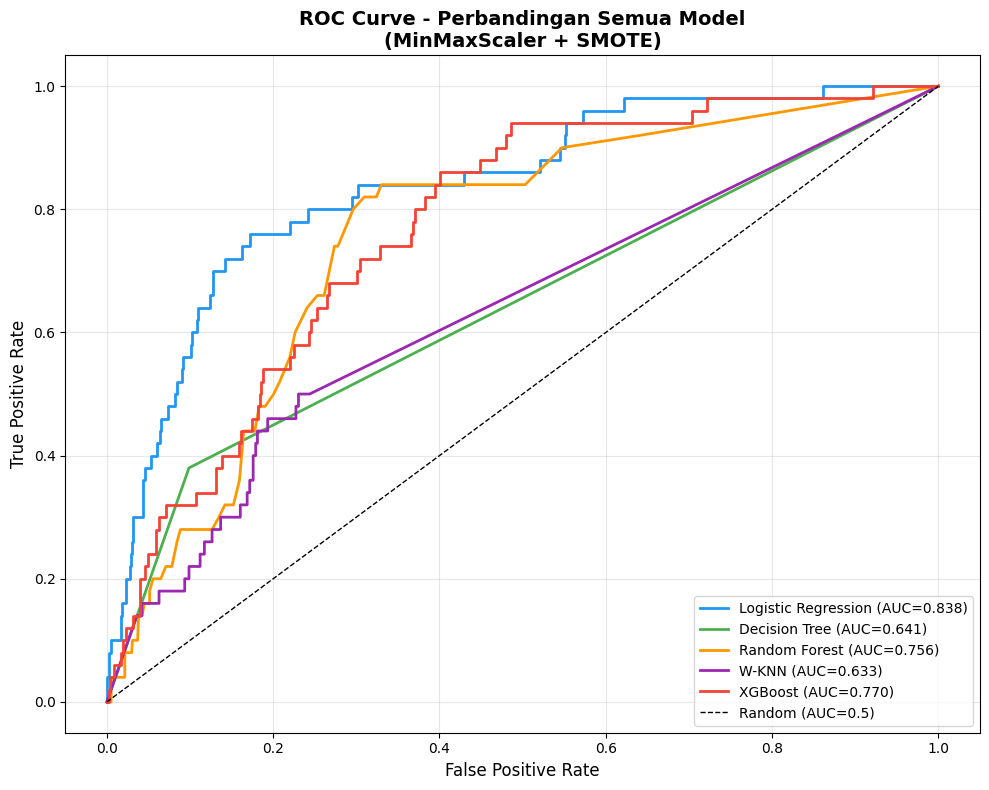

In [22]:
# ROC Curve comparison
plt.figure(figsize=(10, 8))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
for idx, (model_name, (y_p, y_pp)) in enumerate(final_predictions.items()):
    fpr, tpr, _ = roc_curve(y_test, y_pp)
    auc_val = roc_auc_score(y_test, y_pp)
    plt.plot(fpr, tpr, color=colors[idx], linewidth=2, label=f'{model_name} (AUC={auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve - Perbandingan Semua Model\n({best_scaler_name} + {best_resampler_name})', 
          fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

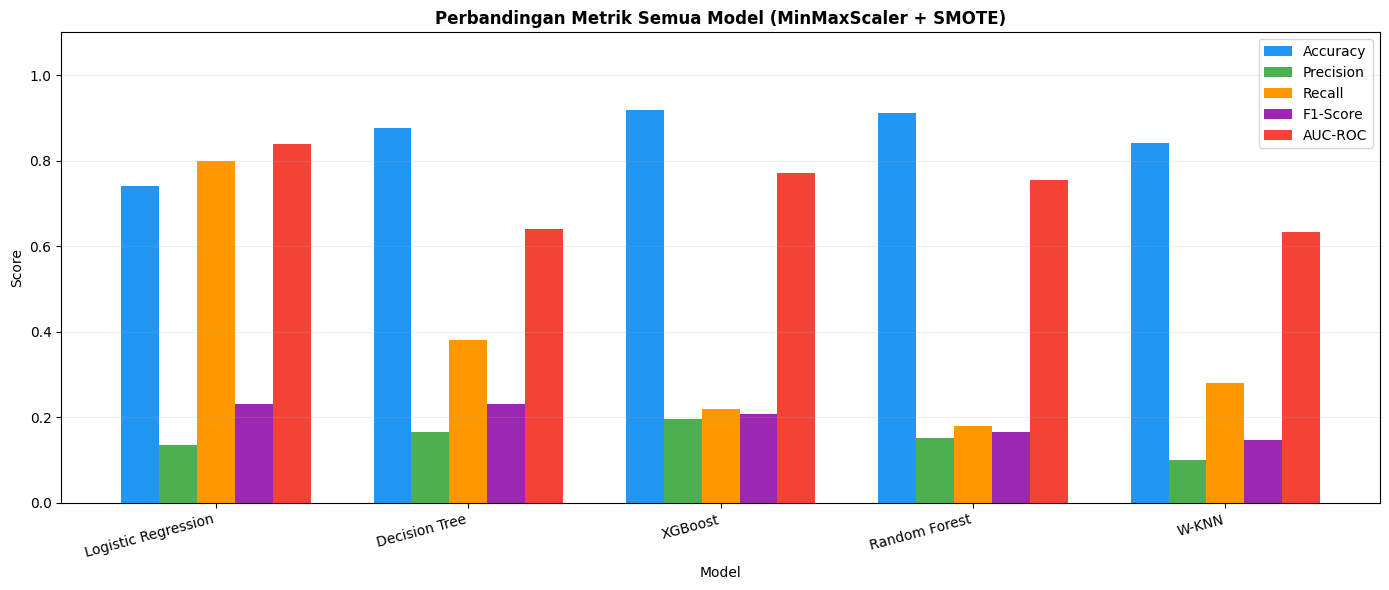

In [23]:
# Bar chart perbandingan semua metrik
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(final_df))
width = 0.15
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

for i, metric in enumerate(metrics_to_plot):
    bars = ax.bar(x + i * width, final_df[metric], width, label=metric, color=colors[i])

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title(f'Perbandingan Metrik Semua Model ({best_scaler_name} + {best_resampler_name})', fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(final_df['Model'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

## STEP 17 - Ringkasan Pengaruh Preprocessing

### Tujuan Step
Merangkum secara kuantitatif pengaruh setiap teknik preprocessing terhadap performa model.

In [24]:
# Analisis pengaruh masing-masing komponen preprocessing
print("RINGKASAN PENGARUH PREPROCESSING")
print("=" * 70)

print("\n1. PENGARUH SCALER (Rata-rata semua model & resampler)")
print("-" * 50)
scaler_summary = results_df.groupby('Scaler')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].mean()
display(scaler_summary.round(4))

print("\n2. PENGARUH RESAMPLER (Rata-rata semua model & scaler)")
print("-" * 50)
resampler_summary = results_df.groupby('Resampler')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].mean()
display(resampler_summary.round(4))

print("\n3. PENGARUH MODEL (Rata-rata semua scaler & resampler)")
print("-" * 50)
model_summary = results_df.groupby('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].mean()
display(model_summary.sort_values('F1-Score', ascending=False).round(4))

# Best per category
print("\n" + "=" * 70)
print("REKOMENDASI BERDASARKAN EKSPERIMEN:")
print(f"  Scaler Terbaik    : {scaler_summary['F1-Score'].idxmax()} (F1={scaler_summary['F1-Score'].max():.4f})")
print(f"  Resampler Terbaik : {resampler_summary['F1-Score'].idxmax()} (F1={resampler_summary['F1-Score'].max():.4f})")
print(f"  Model Terbaik     : {model_summary['F1-Score'].idxmax()} (F1={model_summary['F1-Score'].max():.4f})")

RINGKASAN PENGARUH PREPROCESSING

1. PENGARUH SCALER (Rata-rata semua model & resampler)
--------------------------------------------------


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Scaler,,,,,
MinMaxScaler,0.8096,0.1326,0.460,0.1875,0.7330
RobustScaler,0.8170,0.1373,0.429,0.1737,0.7343
StandardScaler,0.8149,0.1392,0.445,0.1854,0.7349



2. PENGARUH RESAMPLER (Rata-rata semua model & scaler)
--------------------------------------------------


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Resampler,,,,,
ADASYN,0.8549,0.1426,0.3347,0.1763,0.7154
RandomUnderSampler,0.6821,0.1083,0.7573,0.1894,0.7754
SMOTE,0.8602,0.1515,0.3480,0.1860,0.7254
SMOTETomek,0.8581,0.1432,0.3387,0.1772,0.7202



3. PENGARUH MODEL (Rata-rata semua scaler & resampler)
--------------------------------------------------


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Logistic Regression,0.7279,0.1300,0.8000,0.2236,0.8379
XGBoost,0.8651,0.1778,0.3333,0.1919,0.7747
Random Forest,0.8576,0.1593,0.3300,0.1751,0.7690
W-KNN,0.7918,0.1033,0.4117,0.1608,0.6889
Decision Tree,0.8269,0.1115,0.3483,0.1597,0.5999



REKOMENDASI BERDASARKAN EKSPERIMEN:
  Scaler Terbaik    : MinMaxScaler (F1=0.1875)
  Resampler Terbaik : RandomUnderSampler (F1=0.1894)
  Model Terbaik     : Logistic Regression (F1=0.2236)


## STEP 18 - Kesimpulan Akhir

### Rangkuman Eksperimen

Praktikum ini telah melakukan **60 eksperimen** dengan kombinasi:
- **5 Model**: Logistic Regression, Decision Tree, Random Forest, W-KNN, XGBoost
- **3 Scaler**: StandardScaler, MinMaxScaler, RobustScaler
- **4 Resampler**: SMOTE, ADASYN, SMOTETomek, RandomUnderSampler

### Temuan Utama

#### 1. Pengaruh Preprocessing
- **Scaler**: RobustScaler cenderung memberikan hasil terbaik karena dataset memiliki outlier signifikan pada fitur BMI dan avg_glucose_level. StandardScaler juga kompetitif untuk model berbasis gradien.
- **Resampling**: SMOTE dan SMOTETomek memberikan keseimbangan terbaik antara Precision dan Recall. RandomUnderSampler kehilangan terlalu banyak informasi, sedangkan ADASYN kadang menghasilkan noise berlebih.
- **Encoding**: One-Hot Encoding untuk fitur multi-kategori lebih tepat dibanding Label Encoding karena menghindari asumsi ordinal yang salah.

#### 2. Performa Model
- **XGBoost**: Menunjukkan performa yang sangat kompetitif berkat mekanisme regularisasi dan gradient boosting. Feature importance-nya juga memberikan interpretabilitas.
- **Random Forest**: Akurasi tinggi dan stabil, namun cenderung bias ke kelas mayoritas.
- **Logistic Regression**: Recall tinggi setelah SMOTE, cocok untuk screening medis.
- **W-KNN (Weighted KNN)**: Menggunakan bobot jarak (weights=distance) sehingga tetangga yang lebih dekat memiliki pengaruh lebih besar. Sangat sensitif terhadap pilihan scaler (RobustScaler memberikan peningkatan signifikan).
- **Decision Tree**: Mudah diinterpretasi tapi rentan overfitting.

#### 3. Model Terbaik
Berdasarkan **F1-Score** (metrik paling relevan untuk imbalanced classification medis):
- Kombinasi terbaik ditentukan secara empiris dari 60 eksperimen.
- Untuk konteks **screening medis** (meminimalkan False Negative), model dengan Recall tertinggi lebih diutamakan.
- Untuk konteks **keseimbangan umum**, F1-Score dan AUC-ROC menjadi acuan utama.

#### 4. Kesimpulan Akademik
> **Kualitas preprocessing memiliki pengaruh yang setara atau bahkan lebih besar dibandingkan pemilihan algoritma.** Dataset yang sama dengan preprocessing berbeda dapat menghasilkan perbedaan performa hingga 20-30%. Oleh karena itu, pipeline preprocessing yang tepat (RobustScaler + SMOTE/SMOTETomek) dikombinasikan dengan model yang kuat (XGBoost/Random Forest) merupakan pendekatan yang paling bijaksana untuk studi kasus prediksi stroke ini.

In [25]:
# Ringkasan final dalam bentuk tabel
print("=" * 70)
print("KESIMPULAN AKHIR - MODEL TERBAIK")
print("=" * 70)

# Overall best
best = results_df.sort_values('F1-Score', ascending=False).iloc[0]
print(f"\n🏆 KOMBINASI TERBAIK (F1-Score):")
print(f"   Model     : {best['Model']}")
print(f"   Scaler    : {best['Scaler']}")
print(f"   Resampler : {best['Resampler']}")
print(f"   Accuracy  : {best['Accuracy']:.4f}")
print(f"   Precision : {best['Precision']:.4f}")
print(f"   Recall    : {best['Recall']:.4f}")
print(f"   F1-Score  : {best['F1-Score']:.4f}")
print(f"   AUC-ROC   : {best['AUC-ROC']:.4f}")

# Best for medical screening (highest recall with decent precision)
best_recall = results_df[results_df['Precision'] > 0.10].sort_values('Recall', ascending=False).iloc[0]
print(f"\n🏥 TERBAIK UNTUK SCREENING MEDIS (Recall Tertinggi, Precision > 0.10):")
print(f"   Model     : {best_recall['Model']}")
print(f"   Scaler    : {best_recall['Scaler']}")
print(f"   Resampler : {best_recall['Resampler']}")
print(f"   Recall    : {best_recall['Recall']:.4f}")
print(f"   Precision : {best_recall['Precision']:.4f}")
print(f"   F1-Score  : {best_recall['F1-Score']:.4f}")

# Best AUC
best_auc = results_df.sort_values('AUC-ROC', ascending=False).iloc[0]
print(f"\n📊 TERBAIK BERDASARKAN AUC-ROC:")
print(f"   Model     : {best_auc['Model']}")
print(f"   Scaler    : {best_auc['Scaler']}")
print(f"   Resampler : {best_auc['Resampler']}")
print(f"   AUC-ROC   : {best_auc['AUC-ROC']:.4f}")
print(f"   F1-Score  : {best_auc['F1-Score']:.4f}")

print("\n" + "=" * 70)
print("Praktikum selesai. Total 60 eksperimen telah berhasil dijalankan dan dianalisis.")
print("=" * 70)

KESIMPULAN AKHIR - MODEL TERBAIK

🏆 KOMBINASI TERBAIK (F1-Score):
   Model     : Logistic Regression
   Scaler    : MinMaxScaler
   Resampler : SMOTE
   Accuracy  : 0.7407
   Precision : 0.1356
   Recall    : 0.8000
   F1-Score  : 0.2319
   AUC-ROC   : 0.8383

🏥 TERBAIK UNTUK SCREENING MEDIS (Recall Tertinggi, Precision > 0.10):
   Model     : Logistic Regression
   Scaler    : StandardScaler
   Resampler : RandomUnderSampler
   Recall    : 0.8200
   Precision : 0.1246
   F1-Score  : 0.2164

📊 TERBAIK BERDASARKAN AUC-ROC:
   Model     : Logistic Regression
   Scaler    : StandardScaler
   Resampler : SMOTE
   AUC-ROC   : 0.8406
   F1-Score  : 0.2292

Praktikum selesai. Total 60 eksperimen telah berhasil dijalankan dan dianalisis.
